# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь

- Автор: Карманов Владимир
- Дата: 01.06.2026

## Цели и задачи проекта

<font color='#777778'>В этом блоке перечислите цель проекта и те задачи, которые вы решаете. Можно использовать описания проекта, но будет полезно, если вы сформулируете основную цель проекта самостоятельно.</font>

Цель проекта: Подтвердить или опровергнуть то, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

## Описание данных

<font color='#777778'>Здесь приведите описание данных.</font>
Мы будем работать с таблицей `yandex_knigi_data.csv`:
- `city` - название города;
- `puid` - идентификатор пользователя;
- `hours` - общее количество часов активности.

## Содержимое проекта

<font color='#777778'>Перечислите основные шаги проекта или напишите оглавление. Используйте описание проекта, чтобы зафиксировать основные шаги.</font>

Шаги:
- Загрузка данных и знакомство с ними
-  Проверка гипотезы в Python
-  Аналитическая записка

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Пустые ячейки после каждого задания — примерное пространство для работы.
# Вы можете свободно добавлять или удалять ячейки по своему усмотрению в зависимости от логики и объёма работы.

In [2]:
# Используйте ячейки типа Code для вашего кода

In [1]:
import pandas as pd
from scipy import stats as st
from statsmodels.stats.power import NormalIndPower
import numpy as np
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv', index_col=0)

In [3]:
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [4]:
df['city'].value_counts()

Москва             6234
Санкт-Петербург    2550
Name: city, dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
puid_counts=df['puid'].value_counts()
duplicate_puids = puid_counts[puid_counts > 1]
print(f"Пользователей с несколькими записями: {len(duplicate_puids)}")
print(f"Максимальное число записей у одного пользователя: {puid_counts.max()}")
print(f"Примеры пользователей с дубликатами (первые 5):")
print(duplicate_puids.head())

Пользователей с несколькими записями: 244
Максимальное число записей у одного пользователя: 2
Примеры пользователей с дубликатами (первые 5):
879888383     2
73736051      2
331188228     2
16488430      2
1965288031    2
Name: puid, dtype: int64


In [7]:
puid_data1 = df[df['puid'] == 879888383]
print(puid_data1)

                 city       puid     hours
3146           Москва  879888383  0.389974
7454  Санкт-Петербург  879888383  0.080009


In [8]:
puid_data2 = df[df['puid'] == 73736051]
print(puid_data2)

                 city      puid      hours
700            Москва  73736051   0.002778
6490  Санкт-Петербург  73736051  12.434750


In [9]:
puid_data3 = df[df['puid'] == 331188228]
print(puid_data3)

                 city       puid     hours
1620           Москва  331188228  1.146111
6852  Санкт-Петербург  331188228  8.924065


Явных дубликатов не найдено. Неявные дубликаты отличаются, что может показывать, что человек использовал приложение в разных городах.

In [10]:
city_stats = df.groupby('city')['hours'].agg([
    'count',
    'mean',
    'median'
]).round(2)

display(city_stats)

# 4. Анализ выбросов
print("\n" + "="*50)
print("АНАЛИЗ ВЫБРОСОВ")
print("="*50)

def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound

outlier_info = {}
for city in df['city'].unique():
    city_data = df[df['city'] == city]['hours']
    outliers, lb, ub = detect_outliers_iqr(city_data)
    outlier_count = outliers.sum()
    outlier_percent = (outlier_count / len(city_data)) * 100
    outlier_info[city] = {
        'count': outlier_count,
        'percent': round(outlier_percent, 2),
        'bounds': (lb, ub)
    }
    print(f"{city}: {outlier_count} выбросов ({outlier_percent:.2f}%), границы: {lb:.1f}–{ub:.1f}")
    
df_no_outliers = df.copy()
for city, info in outlier_info.items():
    city_data = df_no_outliers[df_no_outliers['city'] == city]
    if info['count'] > 0:
        lb, ub = info['bounds']
        df_no_outliers = df_no_outliers[~(
            (df_no_outliers['city'] == city) &
            ((df_no_outliers['hours'] < lb) | (df_no_outliers['hours'] > ub))
        )]

print(f"\nПосле удаления выбросов: {df_no_outliers.shape[0]} записей")

city_stats_clean = df_no_outliers.groupby('city')['hours'].agg([
    'count',
    'mean',
    'median'
]).round(2)

display(city_stats_clean)

,count,mean,median
city,,,
Москва,6234,10.88,0.92
Санкт-Петербург,2550,11.59,0.98



АНАЛИЗ ВЫБРОСОВ
Москва: 900 выбросов (14.44%), границы: -8.8–14.8
Санкт-Петербург: 385 выбросов (15.10%), границы: -9.6–16.2

После удаления выбросов: 7499 записей


,count,mean,median
city,,,
Москва,5334,2.06,0.49
Санкт-Петербург,2165,2.18,0.55


Выбросы в данных присутствуют, из-за сильного искажения принял решение удалить выбросы.

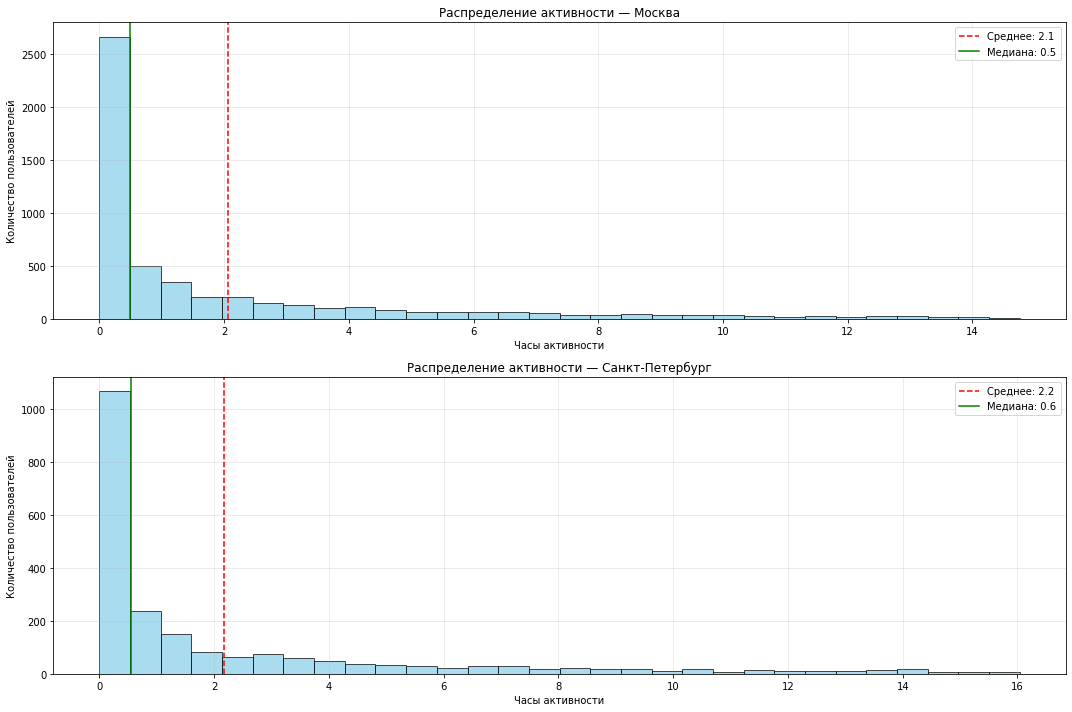

In [11]:
plt.figure(figsize=(15, 10))
cities = df_no_outliers['city'].unique() 
n_cities = len(cities)

for i, city in enumerate(cities, 1):
    plt.subplot(2, (n_cities + 1) // 2, i)  # автоматическая сетка подграфиков
    city_data = df_no_outliers[df_no_outliers['city'] == city]['hours']  # ← теперь данные ПОСЛЕ очистки

    # Строим гистограмму
    plt.hist(city_data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Линии среднего и медианы — тоже по очищенным данным
    mean_val = city_data.mean()
    median_val = city_data.median()
    
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.1f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Медиана: {median_val:.1f}')

    # Оформление графика
    plt.title(f'Распределение активности — {city}')
    plt.xlabel('Часы активности')
    plt.ylabel('Количество пользователей')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()  # улучшаем компоновку
plt.show()

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [12]:
moscow_users = df[df['city'] == 'Москва']['hours']
spb_users = df[df['city'] == 'Санкт-Петербург']['hours']

# Проводим t‑тест Уэлча (односторонний)
t_stat, p_value = st.ttest_ind(
    spb_users,  # первая группа — СПб
    moscow_users,  # вторая группа — Москва
    alternative='greater',  # проверяем: СПб > Москва
    equal_var=False  # используем t‑тест Уэлча
)

print(f"p‑value: {p_value}")

alpha = 0.05

if p_value < alpha:
    print(f' Значение {p_value} меньше, чем {alpha}, значит, что мы отвергаем нулевую гипотезу, значит, что средняя активность в Санкт-Петербурге выше, чем в Москве.')
else:
    print(f' Значение {p_value} больше, чем {alpha}, значит, что мы подтверждаем нулевую гипотезу, значит, что средняя активность не различается.')

p‑value: 0.21823507084569593
 Значение 0.21823507084569593 больше, чем 0.05, значит, что мы подтверждаем нулевую гипотезу, значит, что средняя активность не различается.


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



Вывод:
- В данном проекте был выбран t-тест Уэлча по той причине, что разница между значениями была большой. Уровень статистической значимости α=0.05
- p‑value=0.21823507084569593
- Значение 0.21823507084569593 больше, чем 0.05, значит, что мы подтверждаем нулевую гипотезу, значит, что средняя активность не различается.
- Самая простая и вероятная причина: пользователи из Москвы и Санкт‑Петербурга ведут себя в приложении примерно одинаково. Люди в обоих городах: примерно одинаково используют приложение, имеют схожие привычки, проводят сопоставимое время за чтением и прослушиванием книг.

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Цель: помочь интернет-магазину BitMotion Kit понять, привлечёт ли новых клиентов новый интерфейс сайта или нет.

## 2. Загрузите данные, оцените их целостность.


In [13]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip', compression='zip',
                     parse_dates=['event_dt'], low_memory=False)

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [14]:
# Шаг 1: выделяем пользователей, участвующих в тесте
test_participants = participants[participants['ab_test'] == 'interface_eu_test']
recommender_test = participants[participants['ab_test'] == 'recommender_system_test']

# Шаг 2. Находим пересечение — пользователей, которые есть в обоих тестах
common_users = set(test_participants['user_id']).intersection(set(recommender_test['user_id']))
num_common = len(common_users)

print(f"Найдено {num_common} пользователей, участвующих в обоих тестах:")
if num_common > 0:
    print("Примеры ID пересекающихся пользователей:", list(common_users)[:5])  # первые 5 ID
else:
    print("Пересечений нет — пользователи распределены корректно.")

# Шаг 3. Принимаем решение — удалим пересекающихся пользователей из interface_eu_test
# (чтобы избежать искажения результатов из‑за «смешивания» воздействий)
interface_test_clean = test_participants[~test_participants['user_id'].isin(common_users)].copy()

print(f"\nПосле удаления пересекающихся пользователей:")
print(f"- Было: {len(test_participants)} пользователей в interface_eu_test")
print(f"- Стало: {len(interface_test_clean)} пользователей")

# Шаг 4. Пересчитываем распределение по группам после очистки
group_distribution_clean = interface_test_clean['group'].value_counts()
print("\nНовое распределение пользователей по группам (после очистки):")
print(group_distribution_clean)

# Процентное соотношение после очистки
total_clean = group_distribution_clean.sum()
percentage_A_clean = (group_distribution_clean['A'] / total_clean) * 100
percentage_B_clean = (group_distribution_clean['B'] / total_clean) * 100

print(f"\nПроцентное распределение после очистки:")
print(f"Группа A: {percentage_A_clean:.1f}%")
print(f"Группа B: {percentage_B_clean:.1f}%")

# Шаг 5. Ещё раз проверяем отсутствие пересечений (для уверенности)
user_group_counts_clean = interface_test_clean.groupby('user_id')['group'].nunique()
users_in_multiple_groups_clean = user_group_counts_clean[user_group_counts_clean > 1].index.tolist()
num_common_users_clean = len(users_in_multiple_groups_clean)

if num_common_users_clean == 0:
    print("\nОтлично! После очистки нет пользователей, попавших в обе группы одновременно.")
else:
    print(f"\nВНИМАНИЕ: после очистки всё ещё найдено {num_common_users_clean} пользователей в нескольких группах.")
    print("ID этих пользователей:", users_in_multiple_groups_clean)

Найдено 887 пользователей, участвующих в обоих тестах:
Примеры ID пересекающихся пользователей: ['4122B8F30EB2271C', '341E8DBCD6C8B223', 'D0ECAB9DA4FE2E00', '565EF59DDD36B95B', '505555B3CCA490C8']

После удаления пересекающихся пользователей:
- Было: 10850 пользователей в interface_eu_test
- Стало: 9963 пользователей

Новое распределение пользователей по группам (после очистки):
B    5011
A    4952
Name: group, dtype: int64

Процентное распределение после очистки:
Группа A: 49.7%
Группа B: 50.3%

Отлично! После очистки нет пользователей, попавших в обе группы одновременно.


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [15]:
test_user_ids = test_participants['user_id'].unique()

print(f"Количество уникальных пользователей в тесте: {len(test_user_ids)}")


filtered_events = events[events['user_id'].isin(test_user_ids)]

print(f"Количество событий : {len(filtered_events)}")

Количество уникальных пользователей в тесте: 10850
Количество событий : 79715


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [16]:
registration_events = filtered_events[filtered_events['event_name'] == 'registration']
registration_dates = (
    registration_events.groupby('user_id')['event_dt'].min().reset_index().rename(columns={'event_dt': 'registration_date'})
)
print(f"Найдено регистраций: {len(registration_dates):,}")

# Объединяем события с датами регистрации
events_with_reg = pd.merge(
    filtered_events,
    registration_dates,
    on='user_id',
    how='left'
)


# Рассчитываем лайфтайм (время от регистрации до события в днях)
events_with_reg['lifetime'] = (
    events_with_reg['event_dt'] - events_with_reg['registration_date']
).dt.days

# Фильтруем события за первые 7 дней после регистрации
filtered_7d = events_with_reg[
    (events_with_reg['lifetime'] >= 0) &
    (events_with_reg['lifetime'] <= 7)
]

# Выводим результаты
print(f"\nРЕЗУЛЬТАТЫ АНАЛИЗА:")
print(f"- Всего событий участников теста: {len(filtered_events):,}")
print(f"- С учётом 7‑дневного окна: {len(filtered_7d):,}")

# Дополнительная статистика
print("\nСтатистика по лайфтайму:")
print(filtered_7d['lifetime'].describe())

Найдено регистраций: 10,850

РЕЗУЛЬТАТЫ АНАЛИЗА:
- Всего событий участников теста: 79,715
- С учётом 7‑дневного окна: 71,060

Статистика по лайфтайму:
count    71060.000000
mean         1.292654
std          1.962073
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max          7.000000
Name: lifetime, dtype: float64


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [17]:
# Параметры
baseline_conversion = 0.3      # базовая конверсия — 30 %
mde = 0.03                     # минимальный обнаруживаемый эффект — 3 %
alpha = 0.05                   # уровень значимости (95 % достоверности)
power = 0.8                    # мощность теста — 80 %


effect = proportion_effectsize(baseline_conversion, baseline_conversion + mde)

# Создаём объект для расчёта мощности
analyzer = NormalIndPower()

# Считаем размер выборки на группу
n_per_group = analyzer.solve_power(
    effect_size=effect,
    power=power,
    alpha=alpha,
    ratio=1  # равное число участников в группах A и B
)

print(f"Необходимый размер выборки на группу: {int(n_per_group)}")

Необходимый размер выборки на группу: 3761


- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [18]:
purchase_events = filtered_7d[filtered_7d['event_name'] == 'purchase']

# Получим уникальные ID пользователей, совершивших покупки
users_who_purchased = purchase_events['user_id'].unique()

# Присоединим информацию о группе к пользователям, совершившим покупки
purchasing_users_with_group = test_participants[
    test_participants['user_id'].isin(users_who_purchased)
][['user_id', 'group']]

# Группируем и считаем показатели
group_stats = purchasing_users_with_group.groupby('group').agg(
    purchases=('user_id', 'count')  # число покупок
).reset_index()

# Считаем общее число пользователей в каждой группе
total_users_per_group = test_participants.groupby('group').size().reset_index(name='total_visitors')

# Объединяем данные
final_stats = pd.merge(group_stats, total_users_per_group, on='group')

print("\nСТАТИСТИКА ПО ГРУППАМ:")
print(final_stats)

# Дополнительно — рассчитаем конверсию (%)
final_stats['conversion_rate'] = (final_stats['purchases'] / final_stats['total_visitors']) * 100
print("\nКонверсия по группам (%):")
print(final_stats[['group', 'conversion_rate']].round(2))

conversion_A = final_stats[final_stats['group'] == 'A']['conversion_rate'].values[0]  # группа A
conversion_B = final_stats[final_stats['group'] == 'B']['conversion_rate'].values[0]  # группа B

#  Абсолютный прирост (в процентных пунктах)
absolute_change = conversion_B - conversion_A

#  Относительный прирост (на сколько процентов изменилась метрика относительно контрольной группы)
relative_change_percent = (absolute_change / conversion_A) * 100

print(f"\nАбсолютный прирост: {absolute_change:.2f} п. п.")
print(f"Относительный прирост: {relative_change_percent:+.2f}%")


СТАТИСТИКА ПО ГРУППАМ:
  group  purchases  total_visitors
0     A       1542            5383
1     B       1687            5467

Конверсия по группам (%):
  group  conversion_rate
0     A            28.65
1     B            30.86

Абсолютный прирост: 2.21 п. п.
Относительный прирост: +7.72%


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

На первый взгляд, изменения в тестовой группе положительны: конверсия выше, чем в контрольной. Это может указывать на то, что новый интерфейс оказывает благоприятное влияние на пользовательскую активность.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

- $H_0$: Разница в конверсии не будет отличаться, либо будет приблизительно равной.
- $H_1$: Разница в конверсии будет отличаться

In [19]:
final_stats_sorted = final_stats.sort_values('group').reset_index(drop=True)

purchases_A = final_stats_sorted.loc[0, 'purchases']
purchases_B = final_stats_sorted.loc[1, 'purchases']
total_A = final_stats_sorted.loc[0, 'total_visitors']
total_B = final_stats_sorted.loc[1, 'total_visitors']

# Выполняем z‑тест
counts = [purchases_A, purchases_B]
nobs = [total_A, total_B]
z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

print(f"\nРЕЗУЛЬТАТЫ Z‑ТЕСТА:")
print(f"Статистика z: {z_stat:.3f}")
print(f"p‑value: {p_value:.4f}")

# Интерпретация результата
alpha = 0.05
if p_value < alpha:
    print("Вывод: разница в конверсии статистически значима (отвергаем H₀).")
else:
    print("Вывод: нет достаточных оснований утверждать, что конверсии различаются (не отвергаем H₀).")


РЕЗУЛЬТАТЫ Z‑ТЕСТА:
Статистика z: -2.520
p‑value: 0.0117
Вывод: разница в конверсии статистически значима (отвергаем H₀).


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

Вывод:
- По итогам A/B‑теста выявлено статистически значимое различие в конверсии между группами (p‑value = 0,0117). В тестовой группе B конверсия составила 30,86 %, что на 2,21 выше, чем в контрольной группе A (28,65 %). Рекомендуется внедрить новый интерфейс, так как он положительно влияет на метрику.
- Ожидаемый эффект в изменении в конверсии не был достигнут, но результат довольно близок: 3% и 2.21%